# 05a. Logistic Regression Baseline

## 1. Setup

In [1]:
import os
import sys
from pathlib import Path

project_root = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
os.chdir(project_root)
sys.path.insert(0, str(project_root))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from src.config import TARGET
from src.data.data_cleaning import clean_and_split
from src.evaluation.metrics import evaluate_model, results_to_row
from src.models.logistic_regression import build_logistic_regression_pipeline

figures_dir = project_root / 'experiments' / 'figures'
results_dir = project_root / 'experiments' / 'results'
models_dir = project_root / 'models' / 'baseline'
for directory in (figures_dir, results_dir, models_dir):
    directory.mkdir(parents=True, exist_ok=True)

## 2. Load the cleaned stratified split

Only fixed, row-level cleaning happens before this split. Imputation, encoding, feature selection and scaling remain inside the fitted pipeline so cross-validation does not leak validation-fold information.

In [2]:
train_df, test_df = clean_and_split()
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

pd.DataFrame({
    'rows': [len(X_train), len(X_test)],
    'features': [X_train.shape[1], X_test.shape[1]],
    'default_rate': [y_train.mean(), y_test.mean()],
}, index=['train', 'test'])

,rows,features,default_rate
train,95372,40,0.080988
test,23844,40,0.080985


## 3. Define the baseline

The initial model uses L2 regularisation with `C=1.0`, `class_weight='balanced'`, and a 0.5 classification threshold. These are baseline choices rather than tuned hyperparameters.

In [3]:
logistic_pipeline = build_logistic_regression_pipeline()
logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('score_summary', ...), ('imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,flag_threshold,0.05
,exclude_cols,"['Type_Organization', 'Client_Education', ...]"
,cols,None
,cols,None
,min_freq,0.01
,cols,"['Type_Organization', 'Client_Education', ...]"
,exclude_cols,None


## 4. Five-fold cross-validation

ROC-AUC is the primary ranking metric and PR-AUC is especially informative for the approximately 8% positive class. Recall, precision and F1 describe behaviour at the fixed 0.5 threshold.

In [4]:
cv_results = evaluate_model(
    logistic_pipeline,
    X_train,
    y_train,
    model_name='logistic_regression',
    cv=5,
    threshold=0.5,
)
cv_results_df = results_to_row(cv_results)
cv_results_path = results_dir / 'logistic_regression.csv'
cv_results_df.to_csv(cv_results_path, index=False)
cv_results_df

,model_name,cv_folds,threshold,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,precision_mean,f1_mean,fit_seconds,tn,fp,fn,tp
0,logistic_regression,5,0.5,0.733998,0.005382,0.211638,0.005222,0.668435,0.152915,0.248879,57.96,59048,28600,2561,5163


## 5. Fit the final pipeline and evaluate the held-out test set

In [5]:
fitted_pipeline = build_logistic_regression_pipeline()
fitted_pipeline.fit(X_train, y_train)

test_probability = fitted_pipeline.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= 0.5).astype(int)
test_cm = confusion_matrix(y_test, test_prediction, labels=[0, 1])
tn, fp, fn, tp = test_cm.ravel()

test_results_df = pd.DataFrame([{
    'model_name': 'logistic_regression',
    'threshold': 0.5,
    'accuracy': accuracy_score(y_test, test_prediction),
    'roc_auc': roc_auc_score(y_test, test_probability),
    'pr_auc': average_precision_score(y_test, test_probability),
    'recall': recall_score(y_test, test_prediction),
    'precision': precision_score(y_test, test_prediction, zero_division=0),
    'f1': f1_score(y_test, test_prediction, zero_division=0),
    'tn': int(tn),
    'fp': int(fp),
    'fn': int(fn),
    'tp': int(tp),
}])
test_results_df.to_csv(results_dir / 'logistic_regression_test.csv', index=False)
test_results_df

,model_name,threshold,accuracy,roc_auc,pr_auc,recall,precision,f1,tn,fp,fn,tp
0,logistic_regression,0.5,0.671657,0.742837,0.215429,0.688244,0.15533,0.253457,14686,7227,602,1329


## 6. ROC and precision-recall curves

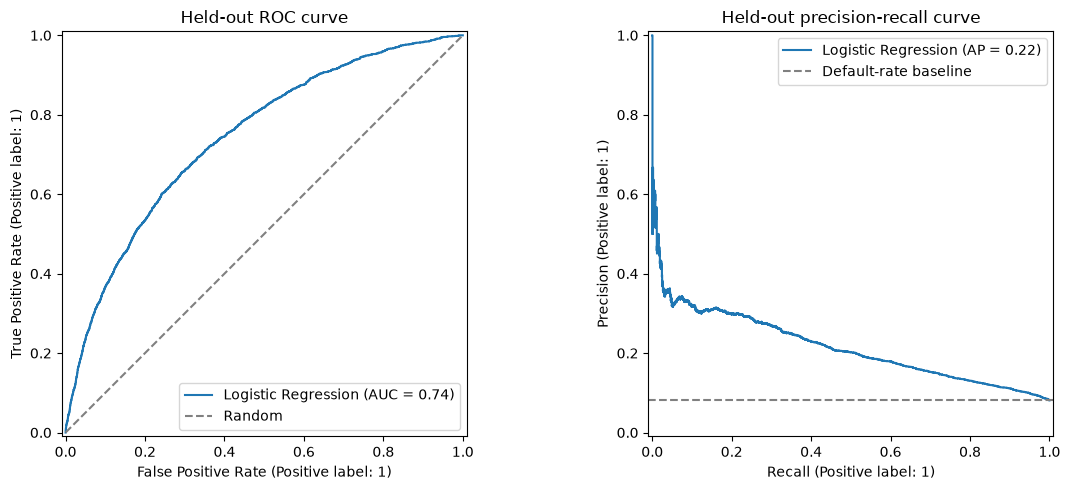

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, test_probability, name='Logistic Regression', ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random')
axes[0].set_title('Held-out ROC curve')
axes[0].legend()
PrecisionRecallDisplay.from_predictions(y_test, test_probability, name='Logistic Regression', ax=axes[1])
axes[1].axhline(y_test.mean(), linestyle='--', color='grey', label='Default-rate baseline')
axes[1].set_title('Held-out precision-recall curve')
axes[1].legend()
fig.tight_layout()
fig.savefig(figures_dir / '05a_logistic_regression_roc_pr.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. Confusion matrix

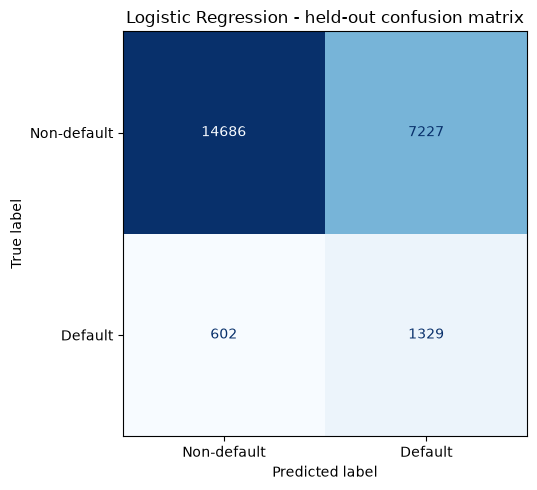

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(test_cm, display_labels=['Non-default', 'Default']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Logistic Regression - held-out confusion matrix')
fig.tight_layout()
fig.savefig(figures_dir / '05a_logistic_regression_confusion_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

## 8. Largest coefficients

Coefficient signs show the direction of association after preprocessing; they are not causal effects. Continuous features are scaled by the shared pipeline, while binary indicators remain unscaled.

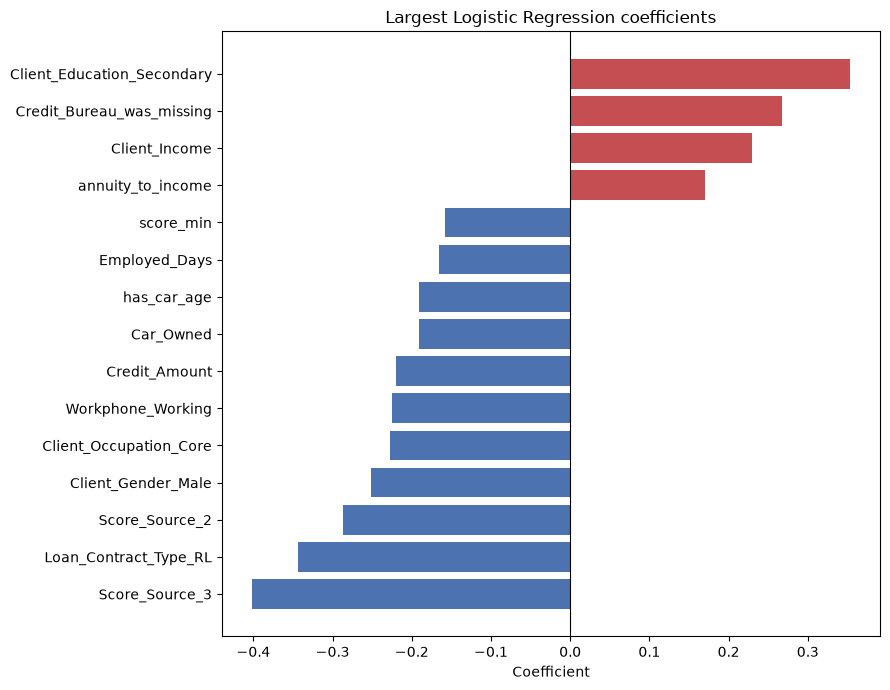

,feature,coefficient
16,Score_Source_3,-0.402117
34,Loan_Contract_Type_RL,-0.343404
15,Score_Source_2,-0.286809
33,Client_Gender_Male,-0.251498
40,Client_Occupation_Core,-0.227007
9,Workphone_Working,-0.224408
3,Credit_Amount,-0.220008
1,Car_Owned,-0.190239
21,has_car_age,-0.190239
5,Employed_Days,-0.165455


In [8]:
transformed_example = fitted_pipeline[:-1].transform(X_train.iloc[[0]])
coefficient_df = pd.DataFrame({
    'feature': transformed_example.columns,
    'coefficient': fitted_pipeline.named_steps['model'].coef_[0],
})
coefficient_df['absolute_coefficient'] = coefficient_df['coefficient'].abs()
top_coefficients = coefficient_df.nlargest(15, 'absolute_coefficient').sort_values('coefficient')

fig, ax = plt.subplots(figsize=(9, 7))
colors = np.where(top_coefficients['coefficient'] >= 0, '#c44e52', '#4c72b0')
ax.barh(top_coefficients['feature'], top_coefficients['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Largest Logistic Regression coefficients')
ax.set_xlabel('Coefficient')
fig.tight_layout()
fig.savefig(figures_dir / '05a_logistic_regression_coefficients.png', dpi=160, bbox_inches='tight')
plt.show()
top_coefficients[['feature', 'coefficient']]

## 9. Save the deployable pipeline

The entire fitted pipeline is saved so production inference can accept the same raw feature schema used by `clean_and_split()`. Model binaries are ignored by Git.

In [9]:
model_path = models_dir / 'logistic_regression.pkl'
joblib.dump(fitted_pipeline, model_path)
print(f'Saved fitted pipeline to: {model_path}')
print(f'Saved CV results to: {cv_results_path}')

Saved fitted pipeline to: c:\Users\yasan\Downloads\Sem 2 - 3rd Year\FDM\FDM-AutoMobile_Loan_Default_Modelling\models\baseline\logistic_regression.pkl
Saved CV results to: c:\Users\yasan\Downloads\Sem 2 - 3rd Year\FDM\FDM-AutoMobile_Loan_Default_Modelling\experiments\results\logistic_regression.csv


## 10. Decision

**Finding:** Five-fold CV produced ROC-AUC 0.734 (+/- 0.005), PR-AUC 0.212 (+/- 0.005), recall 0.668, precision 0.153 and F1 0.249. The held-out test results were consistent: ROC-AUC 0.743, PR-AUC 0.215, recall 0.688, precision 0.155 and F1 0.253. At the default 0.5 threshold the model detected 1,329 of 1,931 defaulters, but also flagged 7,227 non-defaulters.

**Decision:** Retain this as the untuned, interpretable linear baseline. Balanced class weights provide substantially higher recall than the current Random Forest at threshold 0.5, while Random Forest has stronger threshold-free ranking performance. Threshold selection and hyperparameter tuning belong to later project stages and must use validation data rather than the held-out test set.